<a href="https://colab.research.google.com/github/BhushanGatty/multi-armed-bandit-simulation/blob/main/Multi_arm_Bandit_Problem_(Exploration_vs_Exploitation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:105: SyntaxWarning: invalid escape sequence '\e'
<>:105: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4118/1653195085.py:105: SyntaxWarning: invalid escape sequence '\e'
  title=f'$\epsilon$-Greedy Performance on {N_ARMS}-Armed Bandit Task ({N_BANDITS} tasks)'


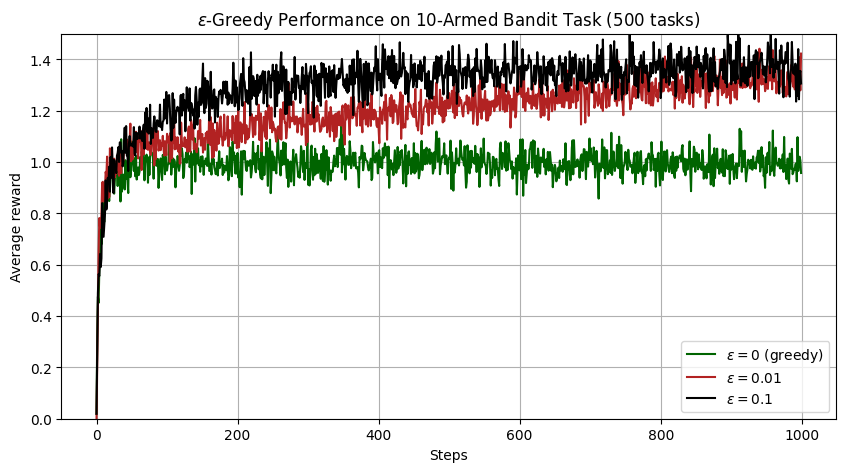

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def run_epsilon_greedy_simulation(n_bandits=500, n_arms=10, n_steps=1000, epsilons=[0, 0.01, 0.1]):
    """
    Runs an epsilon-greedy simulation for a multi-armed bandit problem.

    Args:
        n_bandits (int): Number of independent bandit tasks to simulate.
        n_arms (int): Number of possible actions (arms) for each bandit.
        n_steps (int): Number of steps (interactions) per bandit task.
        epsilons (list): List of epsilon values for the epsilon-greedy strategy.

    Returns:
        np.ndarray: An array containing the average rewards over time for each epsilon value.
    """
    average_rewards = np.zeros((len(epsilons), n_steps))

    # Iterate through each epsilon value
    for i, eps in enumerate(epsilons):
        # Store rewards for all bandit tasks for the current epsilon
        rewards_per_epsilon = np.zeros((n_bandits, n_steps))

        # Simulate each independent bandit task
        for b in range(n_bandits):
            # True (unknown) values for each arm, sampled from a normal distribution
            q_true = np.random.normal(loc=0.0, scale=1.0, size=n_arms)
            # Agent's estimated values for each arm, initialized to zero
            q_estimated = np.zeros(n_arms)
            # Count of how many times each arm has been pulled
            action_counts = np.zeros(n_arms)

            # Simulate interaction for n_steps
            for t in range(n_steps):
                if np.random.rand() < eps:  # Exploration: Choose a random action
                    action = np.random.randint(n_arms)
                else:  # Exploitation: Choose the action with the highest estimated value
                    # Find all actions with the maximum estimated value
                    max_val = np.max(q_estimated)
                    max_actions = np.flatnonzero(q_estimated == max_val)
                    # Randomly break ties among actions with the same max value
                    action = np.random.choice(max_actions)

                # Generate a noisy reward based on the true value of the chosen arm
                reward = np.random.normal(loc=q_true[action], scale=1.0)

                # Update action counts and estimated Q-value incrementally
                action_counts[action] += 1
                q_estimated[action] += (reward - q_estimated[action]) / action_counts[action]
                rewards_per_epsilon[b, t] = reward

        # Calculate the average reward over all bandit tasks for the current epsilon
        average_rewards[i] = np.mean(rewards_per_epsilon, axis=0)

    return average_rewards


def plot_results(average_rewards, epsilons, colors, labels, title=''):
    """
    Plots the average rewards over time for different epsilon-greedy strategies.

    Args:
        average_rewards (np.ndarray): Array of average rewards for each epsilon.
        epsilons (list): List of epsilon values.
        colors (list): List of colors for plotting each line.
        labels (list): List of labels for the legend.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 5))
    for i in range(len(epsilons)):
        plt.plot(average_rewards[i], label=labels[i], color=colors[i])

    plt.title(title if title else r'$\epsilon$-Greedy Performance on Multi-Armed Bandit Task')
    plt.xlabel('Steps')
    plt.ylabel('Average reward')
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1.5) # Set appropriate y-axis limits for reward values
    plt.show()


if __name__ == "__main__":
    # Define simulation constants
    N_BANDITS = 500
    N_ARMS = 10
    N_STEPS = 1000
    EPSILON_VALUES = [0, 0.01, 0.1]
    PLOT_COLORS = ['darkgreen', 'firebrick', 'black']
    PLOT_LABELS = [r'$\epsilon = 0$ (greedy)', r'$\epsilon = 0.01$', r'$\epsilon = 0.1$']

    # Run the simulation
    simulation_average_rewards = run_epsilon_greedy_simulation(
        n_bandits=N_BANDITS,
        n_arms=N_ARMS,
        n_steps=N_STEPS,
        epsilons=EPSILON_VALUES
    )

    # Plot the results
    plot_results(
        simulation_average_rewards,
        epsilons=EPSILON_VALUES,
        colors=PLOT_COLORS,
        labels=PLOT_LABELS,
        title=f'$\epsilon$-Greedy Performance on {N_ARMS}-Armed Bandit Task ({N_BANDITS} tasks)'
    )